In [1]:
from keras.applications import MobileNetV2

from keras.models import Sequential

from keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from keras.utils import img_to_array
from keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

import matplotlib.pyplot as plt

import numpy as np

import cv2

import os

import time

In [2]:
root_dir = r"D:\nhandangsaubenhtrencaylua\nhan dien sau benh tren cay lua\dataset\train_images"

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=15,

    zoom_range=0.15,

    width_shift_range=0.1,

    height_shift_range=0.1,

    horizontal_flip=True,

    brightness_range=[0.8,1.2],

    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(

    root_dir,

    target_size=(224,224),

    batch_size=16,

    class_mode='categorical',

    subset='training'

)

valid_generator = train_datagen.flow_from_directory(

    root_dir,

    target_size=(224,224),

    batch_size=16,

    class_mode='categorical',

    subset='validation'
)

Found 9719 images belonging to 10 classes.
Found 2425 images belonging to 10 classes.


In [4]:
base_model = MobileNetV2(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)
)

9406464/9406464 [==============================] - 12s 1us/step


In [5]:
base_model.trainable = False

In [6]:
model = Sequential()

model.add(base_model)

model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

In [7]:
model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [8]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 2,423,242
Trainable params: 165,258
Non-tr

In [9]:
start_time = time.time()

history = model.fit(

    train_generator,

    validation_data=valid_generator,

    epochs=20,

    verbose=1
)

end_time = time.time()

train_time = end_time - start_time

print("Training Time:", round(train_time,2), "seconds")

Epoch 1/20
608/608 [==============================] - 487s 798ms/step - loss: 1.8303 - accuracy: 0.3303 - val_loss: 1.6313 - val_accuracy: 0.4412
Epoch 2/20
608/608 [==============================] - 334s 549ms/step - loss: 1.6027 - accuracy: 0.4131 - val_loss: 1.5237 - val_accuracy: 0.4586
Epoch 3/20
608/608 [==============================] - 349s 574ms/step - loss: 1.5117 - accuracy: 0.4406 - val_loss: 1.4034 - val_accuracy: 0.5138
Epoch 4/20
608/608 [==============================] - 358s 589ms/step - loss: 1.4494 - accuracy: 0.4610 - val_loss: 1.4259 - val_accuracy: 0.5035
Epoch 5/20
608/608 [==============================] - 358s 589ms/step - loss: 1.4269 - accuracy: 0.4726 - val_loss: 1.3593 - val_accuracy: 0.5369
Epoch 6/20
608/608 [==============================] - 355s 585ms/step - loss: 1.3795 - accuracy: 0.4885 - val_loss: 1.2825 - val_accuracy: 0.5670
Epoch 7/20
608/608 [==============================] - 356s 586ms/step - loss: 1.3568 - accuracy: 0.5012 - val_loss: 1.2721 -

In [10]:
loss, accuracy = model.evaluate(valid_generator)

print("Accuracy:", accuracy * 100)

152/152 [==============================] - 51s 334ms/step - loss: 1.0586 - accuracy: 0.6396
Accuracy: 63.95876407623291


In [11]:
y_pred_prob = model.predict(valid_generator)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = valid_generator.classes

152/152 [==============================] - 53s 344ms/step


In [12]:
precision = precision_score(

    y_true,
    y_pred,

    average='weighted'
)

recall = recall_score(

    y_true,
    y_pred,

    average='weighted'
)

f1 = f1_score(

    y_true,
    y_pred,

    average='weighted'
)

y_true_onehot = to_categorical(
    y_true,
    num_classes=10
)

map_score = average_precision_score(

    y_true_onehot,

    y_pred_prob,

    average='weighted'
)

print("Precision :", precision)

print("Recall    :", recall)

print("F1-score  :", f1)

print("MAP       :", map_score)

Precision : 0.14413742226994763
Recall    : 0.14515463917525773
F1-score  : 0.14056424823430705
MAP       : 0.1391567269654761


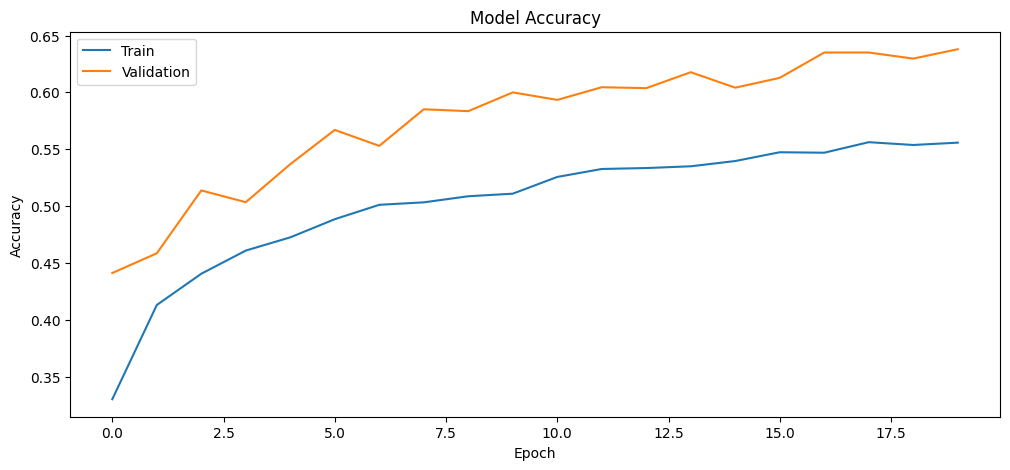

In [13]:
plt.figure(figsize=(12,5))

# Accuracy
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.ylabel("Accuracy")

plt.xlabel("Epoch")

plt.legend(['Train','Validation'])

plt.show()

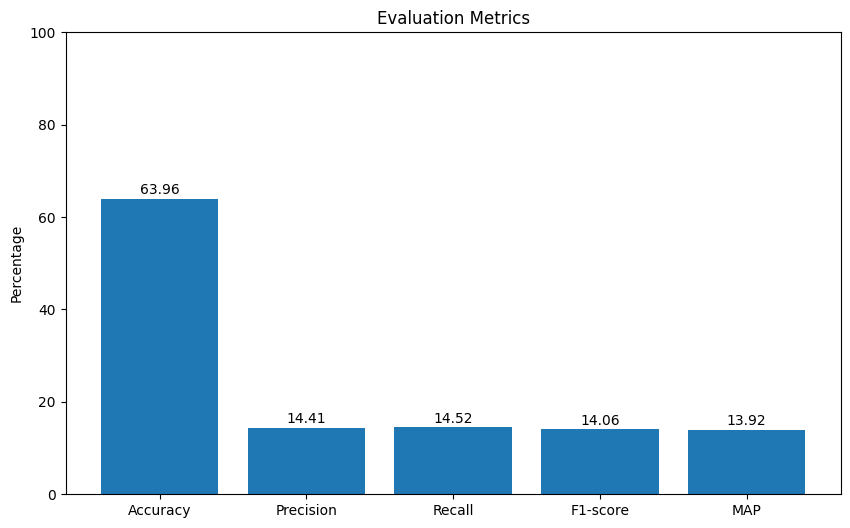

In [14]:
metrics = [

    accuracy * 100,

    precision * 100,

    recall * 100,

    f1 * 100,

    map_score * 100
]

names = [

    "Accuracy",

    "Precision",

    "Recall",

    "F1-score",

    "MAP"
]

plt.figure(figsize=(10,6))

bars = plt.bar(names, metrics)

plt.ylim(0,100)

plt.title("Evaluation Metrics")

plt.ylabel("Percentage")

for bar in bars:

    yval = bar.get_height()

    plt.text(

        bar.get_x() + bar.get_width()/2,

        yval + 1,

        round(yval,2),

        ha='center'
    )

plt.show()